In [1]:
# Standard libraries
import os
import random

# Numerical and Data Processing
import numpy as np  # Linear algebra
import pandas as pd  # Data processing, CSV file I/O (e.g., pd.read_csv)

# PyTorch Data Handling
from torch.utils.data import Dataset, DataLoader

# OpenCV for image processing
import cv2

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Custom utilities and configuration
from utils import visualize, analyze
from data_input import test_dataset,val_dataset,train_dataset
from config import PATH_TEST, PATH_TRAINVAL, SEED, BATCH_SIZE

# NN Framework
import torch
from model import UNet
import torchviz

# Set random seed for reproducibility
random.seed(SEED)


test_image_path = os.path.join(PATH_TEST, 'color/')
test_mask_path = os.path.join(PATH_TEST, 'label/')
test_image_list_orig = os.listdir(test_image_path)
test_mask_list_orig = os.listdir(test_mask_path)

trainval_image_path = os.path.join(PATH_TRAINVAL, 'color/')
trainval_mask_path = os.path.join(PATH_TRAINVAL, 'label/')
trainval_image_list_orig = os.listdir(trainval_image_path)
trainval_mask_list_orig = os.listdir(trainval_mask_path)
image_list = [trainval_image_path+i for i in trainval_image_list_orig]
mask_list = [trainval_mask_path+i for i in trainval_mask_list_orig]
len(trainval_mask_list_orig)

3680

# 0. Image samples Visualization

In [2]:
N = 90

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_list[N], cv2.IMREAD_UNCHANGED)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

# analyze(image, mask)
print(image_list[N],"\n",mask_list[N])

N = 190

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_list[N], cv2.IMREAD_UNCHANGED)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

# analyze(image, mask)
print(image_list[N],"\n",mask_list[N])

Dataset/Dataset/TrainVal/color/British_Shorthair_160.jpg 
 Dataset/Dataset/TrainVal/label/Bombay_159.png
Dataset/Dataset/TrainVal/color/great_pyrenees_172.jpg 
 Dataset/Dataset/TrainVal/label/Siamese_186.png


# Image Input

# 1.  Dataset preprocessing and augmentation

In [3]:


# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Example: Fetch a batch
images, masks = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}, Mask batch shape: {masks.shape}")


Image batch shape: torch.Size([4, 3, 224, 224]), Mask batch shape: torch.Size([4, 224, 224])


/Users/erikasalinasgonzalez/Documents/Master AI/CV/coursework/U-Net-Segmentation/data_input.py:98: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.long)


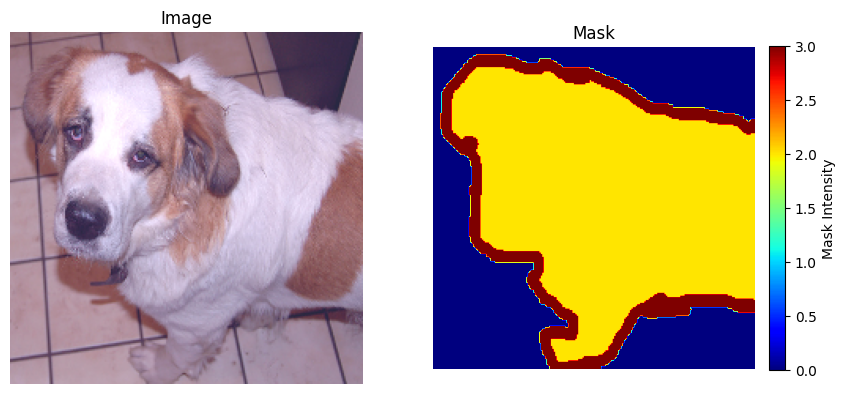

Image shape:  torch.Size([3, 224, 224])


In [14]:
N=random.randint(0,BATCH_SIZE-1)
visualize(images[N].permute(1, 2, 0).numpy(),masks[N])
print("Image shape: ",images[N].shape)

# 2. Segmentation network design and implementation

### 2.a) UNet design and output verification

In [5]:
from model import UNet

model = UNet(input_channels=3, n_filters=64,  n_classes=4)
output = model(images)
print(output.shape)  


torch.Size([4, 4, 224, 224])


##### Output Dimention Verification

Mask shape:  torch.Size([4, 224, 224])


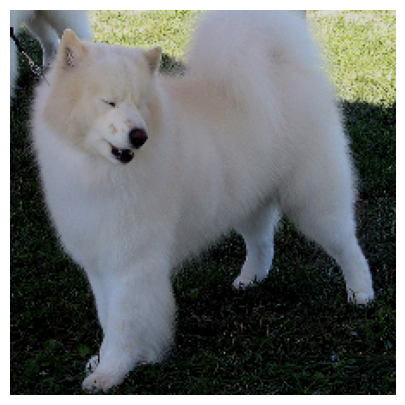

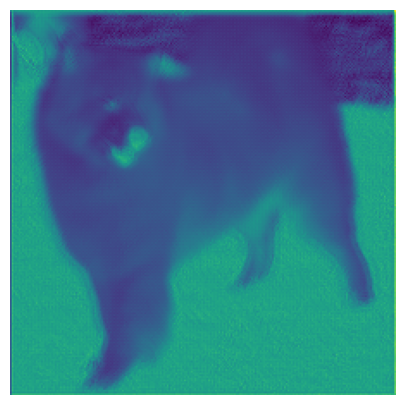

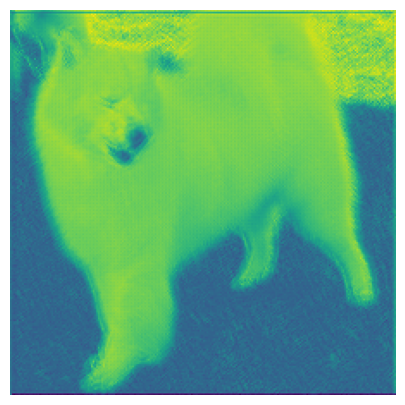

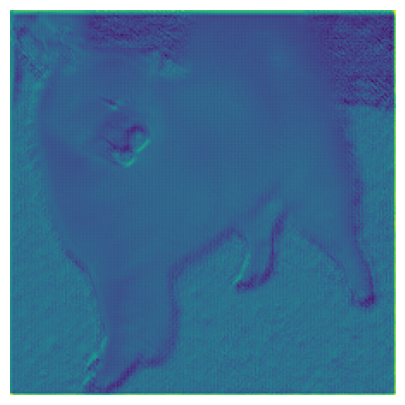

In [6]:
print("Mask shape: ",output[N].shape)
visualize(images[N].permute(1, 2, 0).detach().numpy())
visualize(output[N][0].detach().numpy())
visualize(output[N][1].detach().numpy())
visualize(output[N][2].detach().numpy())



##### The model architecture

### 2.b) Autoencoder pre-training

In [ ]:
from model import Autoencoder
import torch.optim as optim
import torch.nn as nn

retrain = True

# Hyperparameters
batch_size = 4
epochs = 150
learning_rate = 0.0001

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

autoencoder = Autoencoder(input_channels=3, n_filters=64).to(device)
autoencoder.load_state_dict(torch.load("weights/autoencoder_weights_0.0028691928557394854.pth"))
optimizer = optim.Adam(autoencoder.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

if retrain:
    min_loss = 0.00286919
    # Training loop
    for epoch in range(epochs):
        autoencoder.train()
        total_loss = 0

        for images, _ in train_dataloader:  # Ignore masks
            images = images.to(device)

            # Forward pass
            outputs = autoencoder(images)
            loss = criterion(outputs, images)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        avg_loss = total_loss/len(train_dataloader)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")
        if avg_loss < min_loss:
            min_loss = avg_loss
            torch.save(autoencoder.state_dict(), f"weights/autoencoder_weights_{min_loss}.pth")
            print("Model saved.")


/Users/erikasalinasgonzalez/Documents/Master AI/CV/coursework/U-Net-Segmentation/data_input.py:98: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.long)
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Epoch [1/200], Loss: 0.002907


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Epoch [2/200], Loss: 0.002908


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


...

Epoch [45/200], Loss: 0.002870


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Epoch [46/200], Loss: 0.002866


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


KeyboardInterrupt: 

##### Testing Autoencoder's Output

/Users/erikasalinasgonzalez/Documents/Master AI/CV/coursework/U-Net-Segmentation/data_input.py:98: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.long)


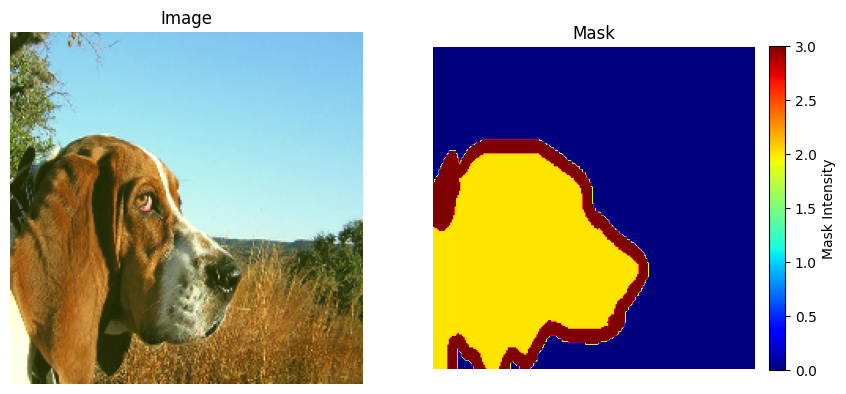

Image shape:  torch.Size([3, 224, 224])


In [25]:
images, masks = next(iter(val_dataloader))
N=random.randint(0,BATCH_SIZE-1)
visualize(images[N].permute(1, 2, 0).numpy(),masks[N])
print("Image shape: ",images[N].shape)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


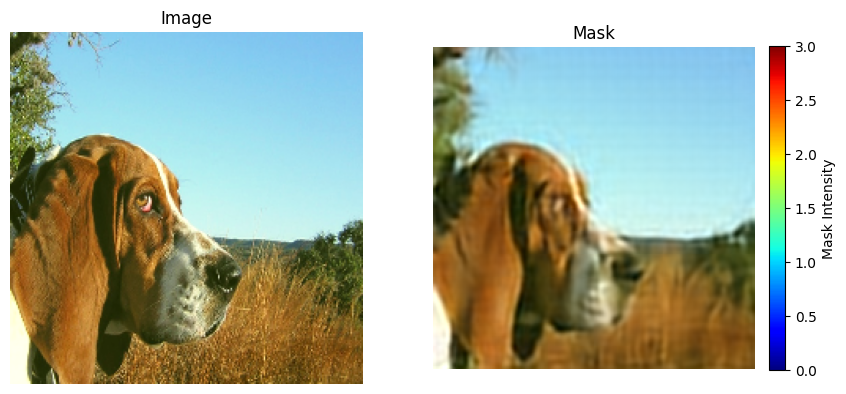

In [26]:
autoencoder.load_state_dict(torch.load("weights/autoencoder_weights_0.0028691928557394854.pth"))
autoencoder.eval()
with torch.no_grad():
    image = images[N].to(device)
    reconstructed = autoencoder(image).cpu().detach().permute(1, 2, 0).numpy()
    original = image.cpu().permute(1, 2, 0).numpy()
visualize(original,reconstructed)